## ThyNet (Thyroid Network for thyroid ultrasound image diagnosis)

### Import packages

In [39]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import torchvision
from torch.utils.tensorboard import SummaryWriter
from torchvision.models import resnet34
from PIL import Image
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, KFold
from sklearn.metrics import roc_auc_score, average_precision_score
from ipywidgets import FloatProgress
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

from glob import glob
import os
import math
from IPython.display import display
import random
import copy
import sys

In [40]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

### Inspect images

In [41]:
#Inspect images
root_dir = "/home/khanh247/Documents/Thac_si/Paper/deep_learning/ThyUS2Path/data/batch1_image/dataset/"  # 69 work station 10T hard drive, containing 0,1,2,3,4,5, five folders.
patient_images_all = [x.split("/")[-1] for x in glob(root_dir + "*.Jpg")]
patient_names = list(set([x.split("_")[0] for x in patient_images_all]))
#Count the number of photos and patients.
print("Num of patient images: ", len(patient_images_all))
print("Num of patients: ", len(patient_names))
del patient_images_all
print(patient_names)
demo_patient = random.choice(patient_names)
demo_patient_im_paths = glob(root_dir + demo_patient + "*")  # one of the patients name.
print(demo_patient_im_paths)  # print all images paths of that patient.

Num of patient images:  6005
Num of patients:  601
['168', '531', '48', '291', '575', '556', '554', '427', '417', '393', '42', '3', '71', '599', '16', '249', '112', '519', '347', '458', '174', '158', '491', '336', '395', '23', '39', '528', '2', '299', '377', '180', '194', '485', '373', '153', '401', '280', '382', '463', '246', '424', '271', '387', '492', '130', '530', '294', '489', '588', '203', '352', '152', '19', '520', '448', '78', '391', '378', '300', '54', '1', '433', '31', '214', '490', '144', '218', '445', '55', '581', '72', '392', '500', '58', '86', '369', '76', '562', '441', '368', '254', '181', '596', '400', '459', '414', '69', '308', '126', '140', '29', '195', '172', '232', '68', '486', '286', '36', '371', '434', '175', '10', '292', '446', '594', '239', '125', '398', '45', '305', '372', '133', '228', '583', '523', '464', '526', '275', '535', '26', '504', '170', '201', '103', '540', '233', '479', '467', '145', '468', '568', '200', '481', '22', '312', '322', '415', '119', '511

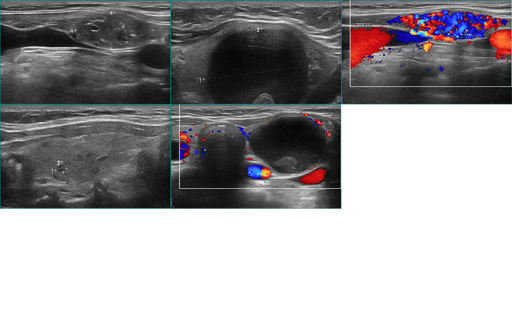

In [42]:
# show images below
def image_concat(image_names):
    """ image_names: list of image paths """
    # 1.creating a background
    image = Image.open(image_names[0])
    image_num = len(image_names)
    background_size = math.ceil(np.sqrt(image_num))
    width, height = image.size
    target_shape = (background_size*width, background_size*height)
    background = Image.new('RGBA', target_shape, (0,0,0,0,))

    # 2.put images into the background
    for ind, image_name in enumerate(image_names):
        img = Image.open(image_name)
        img = img.resize((width, height))  # resize
        if img.mode != "RGBA":             # mode adjusting
            img = img.convert("RGBA")
        row, col = ind//background_size, ind%background_size
        location = (col*width, row*height) # image location in the background
        background.paste(img, location)
    background.thumbnail((512, 512))
    #background.save("./mosaic.png")
    display(background)

image_concat(demo_patient_im_paths)

### Image statistics

In [43]:
root_dir = "./data/batch1_image/dataset/"  # 69 work station 10T hard drive, containing 0,1,2,3,4,5, five folders.
patient_images_all = [x.split("/")[-1] for x in glob(root_dir + "*.Jpg")]
patient_names = [x.split("_")[0] for x in patient_images_all]
folder_0 = pd.DataFrame(pd.value_counts(patient_names)).reset_index()
folder_0.columns = ["patient", "image_nums"]
folder_0["patient_index"] = list(range(len(folder_0)))

root_dir = "/home/khanh247/Documents/Thac_si/Paper/deep_learning/ThyUS2Path/data/batch2_image/dataset/"  # 69 work station 10T hard drive, containing 0,1,2,3,4,5, five folders.
patient_images_all = [x.split("/")[-1] for x in glob(root_dir + "*.Jpg")]
patient_names = [x.split("_")[0] for x in patient_images_all]
folder_1 = pd.DataFrame(pd.value_counts(patient_names)).reset_index()
folder_1.columns = ["patient", "image_nums"]
folder_1["patient_index"] = list(range(len(folder_1)))

root_dir = "/mnt/usb/ultrasound_data/2/"  # 69 work station 10T hard drive, containing 0,1,2,3,4,5, five folders.
patient_images_all = [x.split("/")[-1] for x in glob(root_dir + "*.Jpg")]
patient_names = [x.split("_")[0] for x in patient_images_all]
folder_2 = pd.DataFrame(pd.value_counts(patient_names)).reset_index()
folder_2.columns = ["patient", "image_nums"]
folder_2["patient_index"] = list(range(len(folder_2)))

root_dir = "/mnt/usb/ultrasound_data/3/"  # 69 work station 10T hard drive, containing 0,1,2,3,4,5, five folders.
patient_images_all = [x.split("/")[-1] for x in glob(root_dir + "*.Jpg")]
patient_names = [x.split("_")[0] for x in patient_images_all]
folder_3 = pd.DataFrame(pd.value_counts(patient_names)).reset_index()
folder_3.columns = ["patient", "image_nums"]
folder_3["patient_index"] = list(range(len(folder_3)))

root_dir = "/mnt/usb/ultrasound_data/4/"  # 69 work station 10T hard drive, containing 0,1,2,3,4,5, five folders.
patient_images_all = [x.split("/")[-1] for x in glob(root_dir + "*.Jpg")]
patient_names = [x.split("_")[0] for x in patient_images_all]
folder_4 = pd.DataFrame(pd.value_counts(patient_names)).reset_index()
folder_4.columns = ["patient", "image_nums"]
folder_4["patient_index"] = list(range(len(folder_4)))

root_dir = "/mnt/usb/ultrasound_data/5/"  # 69 work station 10T hard drive, containing 0,1,2,3,4,5, five folders.
patient_images_all = [x.split("/")[-1] for x in glob(root_dir + "*.Jpg")]
patient_names = [x.split("_")[0] for x in patient_images_all]
folder_5 = pd.DataFrame(pd.value_counts(patient_names)).reset_index()
folder_5.columns = ["patient", "image_nums"]
folder_5["patient_index"] = list(range(len(folder_5)))

root_dir = "/mnt/usb/ultrasound_data/miss_data/"
patient_images_all = [x.split("/")[-1] for x in glob(root_dir + "*.Jpg")]
patient_names = [x.split("_")[0] for x in patient_images_all]
folder_6 = pd.DataFrame(pd.value_counts(patient_names)).reset_index()
folder_6.columns = ["patient", "image_nums"]
folder_6["patient_index"] = list(range(len(folder_6)))


/tmp/ipykernel_2967288/4223751624.py:4: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  folder_0 = pd.DataFrame(pd.value_counts(patient_names)).reset_index()
/tmp/ipykernel_2967288/4223751624.py:4: FutureWarning: value_counts with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  folder_0 = pd.DataFrame(pd.value_counts(patient_names)).reset_index()
/tmp/ipykernel_2967288/4223751624.py:11: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  folder_1 = pd.DataFrame(pd.value_counts(patient_names)).reset_index()
/tmp/ipykernel_2967288/4223751624.py:11: FutureWarning: value_counts with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  folder_1 = pd.DataFrame(pd.value_counts(pati

In [44]:
merged_df = pd.concat([folder_0, folder_1, folder_2, folder_3, folder_4, folder_5, folder_6])
merged_df

,patient,image_nums,patient_index
0,449,31,0.0
1,528,30,1.0
2,91,29,2.0
3,224,28,3.0
4,336,27,4.0
...,...,...,...
237,71,3,237.0
238,67,3,238.0
239,65,3,239.0
240,98,3,240.0


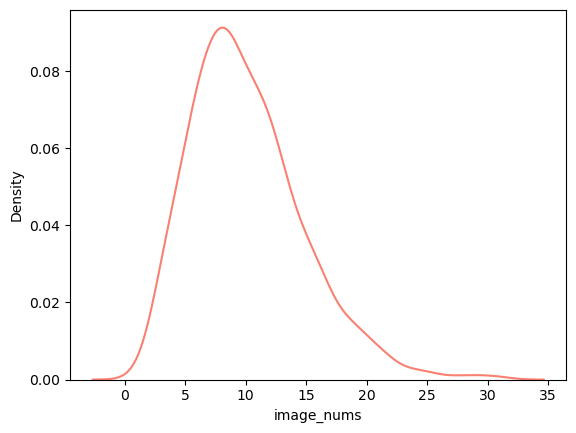

In [45]:
sns.kdeplot(x="image_nums", data=merged_df, color="salmon")
plt.savefig("image_num_stats.svg", format="svg")

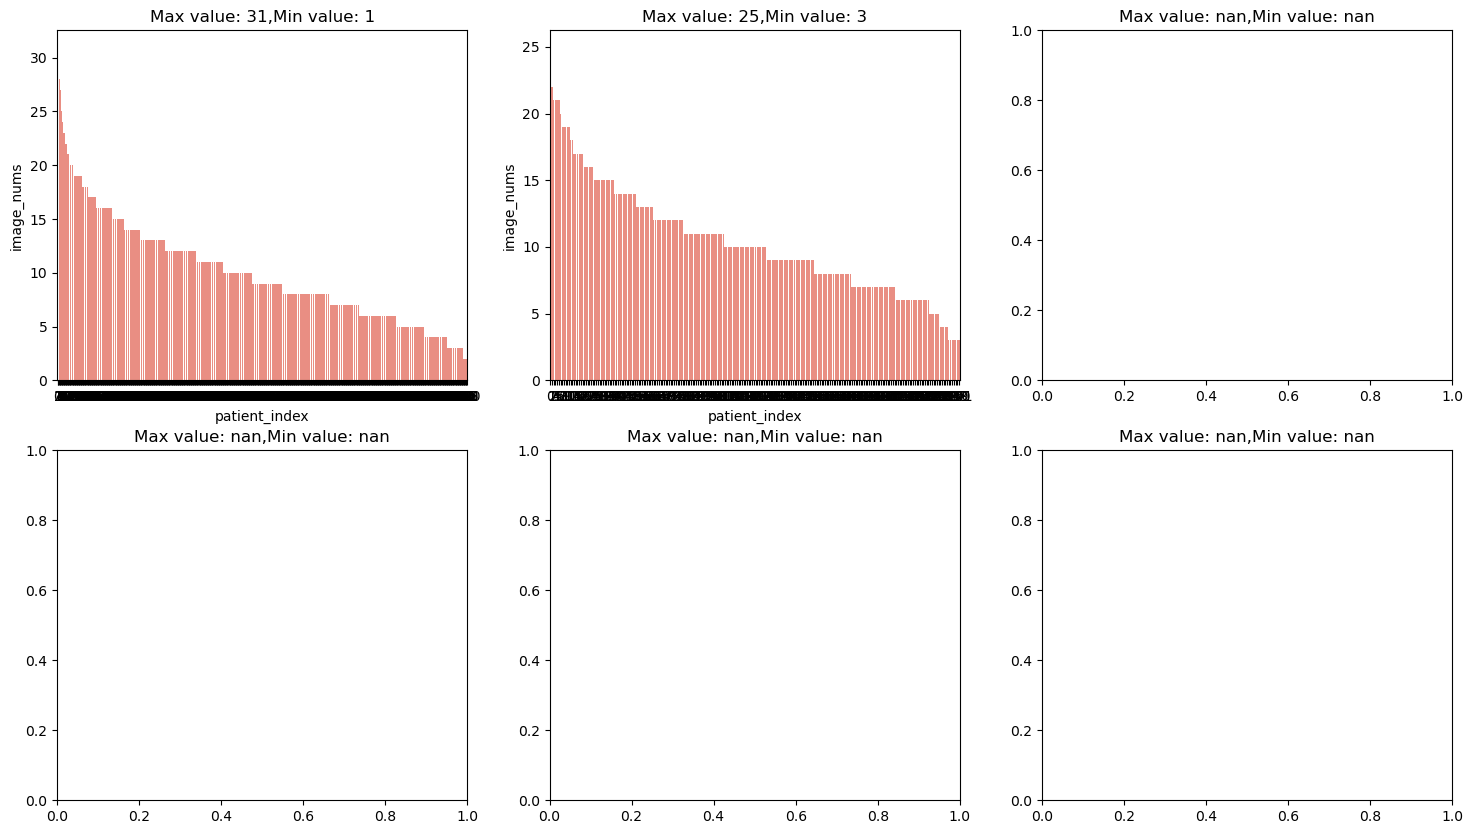

In [46]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
sns.barplot(ax=axes[0, 0], x="patient_index", y="image_nums", data=folder_0, color="salmon")
axes[0, 0].set_title("Max value: " + str(folder_0.max().image_nums) + "," + "Min value: " + str(folder_0.min().image_nums))
sns.barplot(ax=axes[0, 1], x="patient_index", y="image_nums", data=folder_1, color="salmon")
axes[0, 1].set_title("Max value: " + str(folder_1.max().image_nums) + "," + "Min value: " + str(folder_1.min().image_nums))
sns.barplot(ax=axes[0, 2], x="patient_index", y="image_nums", data=folder_2, color="salmon")
axes[0, 2].set_title("Max value: " + str(folder_2.max().image_nums) + "," + "Min value: " + str(folder_2.min().image_nums))
sns.barplot(ax=axes[1, 0], x="patient_index", y="image_nums", data=folder_3, color="salmon")
axes[1, 0].set_title("Max value: " + str(folder_3.max().image_nums) + "," + "Min value: " + str(folder_3.min().image_nums))
sns.barplot(ax=axes[1, 1], x="patient_index", y="image_nums", data=folder_4, color="salmon")
axes[1, 1].set_title("Max value: " + str(folder_4.max().image_nums) + "," + "Min value: " + str(folder_4.min().image_nums))
sns.barplot(ax=axes[1, 2], x="patient_index", y="image_nums", data=folder_5, color="salmon")
axes[1, 2].set_title("Max value: " + str(folder_5.max().image_nums) + "," + "Min value: " + str(folder_5.min().image_nums))
plt.show()

### Create Dataset

#### Generate image path csv file from folder 0, 1, 2, 3, 4, 5, miss_data

In [47]:
# def generate_csv(root_dir, csv_path):
#     os.makedirs(csv_path, exist_ok=True)
#     images_paths = glob(root_dir + "*/*.Jpg")
#     df = pd.DataFrame(images_paths)
#     df.columns = ["path"]
#     df["patient_name"] = df["path"].map(lambda x: x.split("/")[-1].split("_")[0])
#     print(df)
#     df.to_csv(os.path.join(csv_path, "image_paths.csv"), index=False, encoding="utf_8_sig")  # encoding=utf-8 in case that Chinsese
#     print("===Saved %s to %s====" % ("image_paths.csv", csv_path))
#     return df

In [48]:
# root_dir = "/home/khanh247/Documents/Thac_si/Paper/deep_learning/ThyUS2Path/data/batch1_image/dataset/"
# csv_path = "/home/khanh247/Documents/Thac_si/Paper/deep_learning/ThyUS2Path/data/batch1_image"
# df = generate_csv(root_dir, csv_path)

#### Load patient information csv
- Load case_info.csv from ./data folder
- Load patient_index_name.csv from ./data folder

In [49]:
# load case_info.csv from ./data folder
case_info_csv = "/home/khanh247/Documents/Thac_si/Paper/deep_learning/ThyUS2Path/data/batch1_image/batch1_image_label.csv"
case_info_df = pd.read_csv(case_info_csv, encoding='utf-8-sig')

print("=== COLUMN NAMES IN THE FILE ===")
print(case_info_df.columns.tolist())
print("\n=== Three first lines ===")
print(case_info_df.head(3))
case_info_part = case_info_df[["patient_name", "histo_label"]].copy()
case_info_part = case_info_part.dropna().astype({"patient_name": str, "histo_label": int})
case_info_part

=== COLUMN NAMES IN THE FILE ===
['patient_name', 'histo_label']

=== Three first lines ===
   patient_name  histo_label
0           502            0
1           288            1
2           323            0


,patient_name,histo_label
0,502,0
1,288,1
2,323,0
3,178,0
4,427,1
...,...,...
596,9,1
597,373,1
598,541,1
599,305,1


In [50]:
# Đường dẫn file label
label_csv = "/home/khanh247/Documents/Thac_si/Paper/deep_learning/ThyUS2Path/data/batch1_image/batch1_image_label.csv"
df_label = pd.read_csv(label_csv)

# Tạo danh sách patient_name duy nhất, sắp xếp để ổn định
patient_names = sorted(df_label['patient_name'].astype(str).unique())
print(f"Total unique patients: {len(patient_names)}")

# Tạo DataFrame
patient_index_name_df = pd.DataFrame({
    'patient_index': range(len(patient_names)),
    'patient_name': patient_names
})

# Tạo thư mục ./data nếu chưa có
os.makedirs("./data", exist_ok=True)

# Lưu file
patient_index_name_csv = "./data/patient_index_name.csv"
patient_index_name_df.to_csv(patient_index_name_csv, index=False, encoding='utf-8-sig')

print(f"\nĐÃ TẠO FILE: {patient_index_name_csv}")
print("10 dòng đầu:")
print(patient_index_name_df.head(10))

Total unique patients: 601

ĐÃ TẠO FILE: ./data/patient_index_name.csv
10 dòng đầu:
   patient_index patient_name
0              0            0
1              1            1
2              2           10
3              3          100
4              4          101
5              5          102
6              6          103
7              7          104
8              8          105
9              9          106


In [51]:
# Load file vừa tạo
patient_index_name_csv = "./data/patient_index_name.csv"
patient_index_name_df = pd.read_csv(patient_index_name_csv)
patient_index_name_df.sort_values("patient_index", inplace=True)

print("LOAD THÀNH CÔNG!")
print(patient_index_name_df.head(10))

LOAD THÀNH CÔNG!
   patient_index  patient_name
0              0             0
1              1             1
2              2            10
3              3           100
4              4           101
5              5           102
6              6           103
7              7           104
8              8           105
9              9           106


In [52]:
# STEP 3: MERGE WITH LABEL (histo_label)

# Load label (if not already present)
label_csv = "/home/khanh247/Documents/Thac_si/Paper/deep_learning/ThyUS2Path/data/batch1_image/batch1_image_label.csv"
df_label = pd.read_csv(label_csv)
case_info_part = df_label[["patient_name", "histo_label"]].copy()

# MAKE SURE patient_name IS A STRING ON BOTH SIDES
patient_index_name_df["patient_name"] = patient_index_name_df["patient_name"].astype(str)
case_info_part["patient_name"] = case_info_part["patient_name"].astype(str)

# Merge
merged_df = pd.merge(patient_index_name_df, case_info_part, on="patient_name", how="left")

# Check
print(f"Total patients: {len(merged_df)}")
print(f"Missing label: {merged_df['histo_label'].isna().sum()}")

# Save file
os.makedirs("./tmp", exist_ok=True)
merged_df.to_csv("./tmp/patient_name_label.csv", index=False, encoding='utf-8-sig')

print("\nMERGE Successfully!")
print("Label distribution:")
print(merged_df["histo_label"].value_counts())
print("\n10 first lines:")
print(merged_df.head(10))

Total patients: 601
Missing label: 0

MERGE Successfully!
Label distribution:
histo_label
1    383
0    218
Name: count, dtype: int64

10 first lines:
   patient_index patient_name  histo_label
0              0            0            1
1              1            1            0
2              2           10            0
3              3          100            0
4              4          101            1
5              5          102            1
6              6          103            0
7              7          104            1
8              8          105            1
9              9          106            1


In [53]:
merged_df.histo_label.value_counts()

histo_label
1    383
0    218
Name: count, dtype: int64

In [54]:
merged_df.patient_name.value_counts()

patient_name
0      1
454    1
456    1
457    1
458    1
      ..
28     1
280    1
281    1
282    1
99     1
Name: count, Length: 601, dtype: int64

#### Rename patients with duplicated name
- Because there may be some duplicated patient names, we need to rename these patients in both ./tmp/image_paths.csv and ./tmp/patient_name_label.csv
- Upload the modified image_paths.csv and patient_name_label.csv to ./tmp folder again
- We also copy a backup of image_paths.csv and patient_name_label.csv in ./tmp/backup folder in case these csv files are deleted or overwrited accidently.

#### Build dataset

In [55]:
class ThyDataset(Dataset):
    
    def __init__(self, csv1_path, csv2_path, transform=None):
        """
        csv1_path: image_paths.csv in ./tmp folder
        csv2_path: patient_name_label.csv in ./tmp folder
        """
        self.df = pd.read_csv(csv1_path)
        self.unique_patients = list(set(self.df.patient_name))
        self.unique_patients.sort(key=list(self.df.patient_name).index)
        self.ref_df = pd.read_csv(csv2_path)
        self.transform = transform
        self.root_dir = root_dir
        self.patient = None
        
    def __len__(self):
        return len(self.unique_patients)
    
    def __getitem__(self, index):
        images = []
        self.patient = self.unique_patients[index]
        label = self.ref_df[self.ref_df['patient_name']== self.patient].histo_label.item()
        image_paths_of_this_patient = list(self.df.path[self.df.patient_name == self.patient])
        for image_path in image_paths_of_this_patient:
            image = Image.open(image_path)
            if self.transform is not None:
                image = self.transform(image)
            images.append(image)
        images = torch.stack(images, dim=0)
        return images, label, self.patient

In [56]:
import os
import pandas as pd
#Filter valid images(full path)
def filter_missing_images(csv_path, root_dir, image_col="path", save_clean_csv=True):
    df = pd.read_csv(csv_path)
    if image_col not in df.columns:
        raise ValueError(f"Column '{image_col}' not found")

    # Create full path
    df["full_path"] = df[image_col].apply(lambda x: os.path.join(root_dir, str(x)))
    df["full_path_checked"] = df["full_path"].apply(
        lambda x: x if os.path.exists(x) else x.replace(".Jpg", ".jpg")
    )

    exists_mask = df["full_path_checked"].apply(os.path.exists)
    df_missing = df[~exists_mask]
    df_clean = df[exists_mask].reset_index(drop=True)

    print(f"Valid images: {len(df_clean)}")
    print(f"Missing images: {len(df_missing)}")

    # Save missing
    missing_path = os.path.join(os.path.dirname(csv_path), "missing_images.csv")
    df_missing.to_csv(missing_path, index=False)

    # Save filtered_images.csv with path = full_path_checked
    if save_clean_csv:
        clean_path = os.path.join(os.path.dirname(csv_path), "filtered_images.csv")
        df_save = df_clean[['patient_name', 'full_path_checked']].copy()
        df_save.columns = ['patient_name', 'path']  # Change name column
        df_save.to_csv(clean_path, index=False, encoding='utf-8-sig')
        print(f"FILTERED CSV (FULL PATH) SAVED: {clean_path}")

    return df_clean

In [57]:
csv_path = "/home/khanh247/Documents/Thac_si/Paper/deep_learning/ThyUS2Path/data/batch1_image/batch1_image.csv"
root_dir = "/home/khanh247/Documents/Thac_si/Paper/deep_learning/ThyUS2Path/data/batch1_image/dataset/"

df_clean = filter_missing_images(csv_path, root_dir, image_col="path", save_clean_csv=True)

Valid images: 3398
Missing images: 2606
FILTERED CSV (FULL PATH) SAVED: /home/khanh247/Documents/Thac_si/Paper/deep_learning/ThyUS2Path/data/batch1_image/filtered_images.csv


In [58]:
import os
import pandas as pd

# --- Path ---
csv_input = "/home/khanh247/Documents/Thac_si/Paper/deep_learning/ThyUS2Path/data/batch1_image/batch1_image.csv"
image_folder = "/home/khanh247/Documents/Thac_si/Paper/deep_learning/ThyUS2Path/data/batch1_image/dataset"
csv_output = "/home/khanh247/Documents/Thac_si/Paper/deep_learning/ThyUS2Path/data/batch1_image/batch1_image_valid.csv"

# --- Read CSV ---
df = pd.read_csv(csv_input)

# --- Get the real image file name (lowercase, remove path) ---
valid_images = {f.lower() for f in os.listdir(image_folder)}

# --- Normalize path column in CSV ---
# Nếu cột "path" có chứa đường dẫn (ví dụ data/batch1_image/dataset/239_001.Jpg)
# thì ta chỉ lấy phần tên file cuối cùng:
df["filename"] = df["path"].apply(lambda p: os.path.basename(str(p)).lower())

# --- Filter out image files that actually exist ---
filtered_df = df[df["filename"].isin(valid_images)].drop(columns=["filename"])

# --- Export to new file ---
filtered_df.to_csv(csv_output, index=False)

print(f"✅ Đã tạo '{csv_output}' với {len(filtered_df)} ảnh hợp lệ.")
print(f"❌ {len(df) - len(filtered_df)} ảnh bị thiếu hoặc sai tên.")


✅ Đã tạo '/home/khanh247/Documents/Thac_si/Paper/deep_learning/ThyUS2Path/data/batch1_image/batch1_image_valid.csv' với 3398 ảnh hợp lệ.
❌ 2606 ảnh bị thiếu hoặc sai tên.


In [59]:
#Preprocess images
transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])
#Create dataset from two CSV files
csv1_path = "/home/khanh247/Documents/Thac_si/Paper/deep_learning/ThyUS2Path/data/batch1_image/batch1_image_valid.csv"
csv2_path = "/home/khanh247/Documents/Thac_si/Paper/deep_learning/ThyUS2Path/data/batch1_image/batch1_image_label.csv"
dataset = ThyDataset(csv1_path=csv1_path, csv2_path=csv2_path, transform=transform)

In [60]:
root_dir = "/home/khanh247/Documents/Thac_si/Paper/deep_learning/ThyUS2Path/data/batch1_image/dataset/"
dataset.df["path"] = dataset.df["path"].apply(lambda x: os.path.join(root_dir, x))


In [61]:
dataset.df

,patient_name,path
0,341,/home/khanh247/Documents/Thac_si/Paper/deep_le...
1,341,/home/khanh247/Documents/Thac_si/Paper/deep_le...
2,341,/home/khanh247/Documents/Thac_si/Paper/deep_le...
3,341,/home/khanh247/Documents/Thac_si/Paper/deep_le...
4,341,/home/khanh247/Documents/Thac_si/Paper/deep_le...
...,...,...
3393,336,/home/khanh247/Documents/Thac_si/Paper/deep_le...
3394,336,/home/khanh247/Documents/Thac_si/Paper/deep_le...
3395,336,/home/khanh247/Documents/Thac_si/Paper/deep_le...
3396,336,/home/khanh247/Documents/Thac_si/Paper/deep_le...


In [62]:
# check the dataset loading
all_labels = []
for tensor, label, patient in tqdm(dataset):
    all_labels.append(label)
    print(patient)

  0%|          | 0/496 [00:00<?, ?it/s]

341
92
104
279
184
114
484
544
261
447
598
516
507
128
525
41
338
65
311
321
234
99
303
196
561
118
275
21
566
489
256
593
39
88
344
356
524
120
191
511
132
505
488
173
68
109
590
540
361
462
237
228
408
223
485
117
352
206
468
106
424
266
162
153
411
96
91
463
482
125
589
416
531
49
298
444
47
164
190
285
137
163
31
85
378
5
373
466
251
38
541
305
538
397
393
232
346
536
385
443
72
555
10
263
565
169
233
265
476
52
480
126
71
75
33
45
146
218
452
392
103
547
6
17
498
398
193
167
64
1
80
236
70
327
542
312
333
205
390
448
574
42
81
512
309
299
572
8
582
478
136
140
133
253
520
429
292
432
552
348
286
571
412
242
26
514
559
585
472
449
231
287
509
189
349
98
345
293
422
301
220
62
82
529
581
144
27
74
36
200
425
282
401
486
420
130
521
174
260
508
244
586
499
248
387
60
570
258
316
54
243
550
300
382
113
469
450
127
465
24
539
315
111
148
402
276
587
335
29
37
399
100
325
93
470
2
97
89
304
591
381
317
250
274
409
364
579
159
53
543
329
156
139
306
368
442
270
46
307
553
455
178
554
353

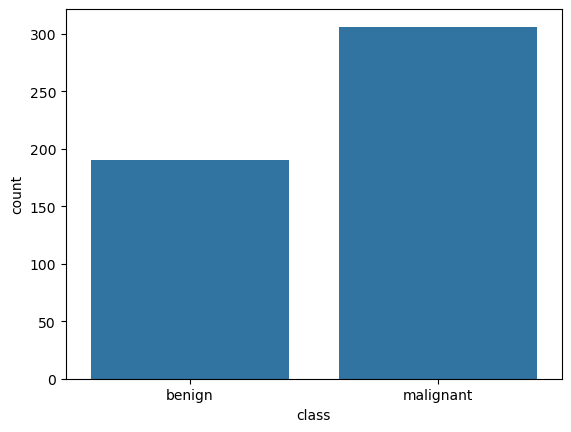

,count,class
0,190,benign
1,306,malignant


In [63]:
# inspect the labels
plt.cla()
labels_df = pd.DataFrame([all_labels.count(0), all_labels.count(1)],
                         columns=["count"])
labels_df["class"] = ["benign", "malignant"]
sns.barplot(x="class", y="count", data=labels_df)
plt.savefig("bar.svg", format="svg")
plt.show()
labels_df

In [64]:
#Means:
#"Tổng số bệnh nhân: 190 + 306 = 496
#Dữ liệu mất cân bằng: malignant > benign → cần class weight hoặc oversampling nếu cần.
#Đảm bảo nhãn đúng: 0 = benign, 1 = malignant

In [65]:
# visualize a few images
def imshow(inp, title=None, savename=None):
    """Imshow for Tensor."""
    inp = inp.numpy().transpose((1, 2, 0))
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    inp = std * inp + mean
    inp = np.clip(inp, 0, 1)
    plt.imshow(inp)
    plt.axis("off")
    if savename is not None:
        plt.savefig(savename, format="svg")
    plt.show()
    if title is not None:
        plt.title(title)
    plt.pause(0.001) 

In [66]:
#Vì Normalize đã trừ mean, chia std → ảnh thành số âm → không hiển thị được.
#→ Phải cộng lại mean, nhân std để đưa về [0,1]

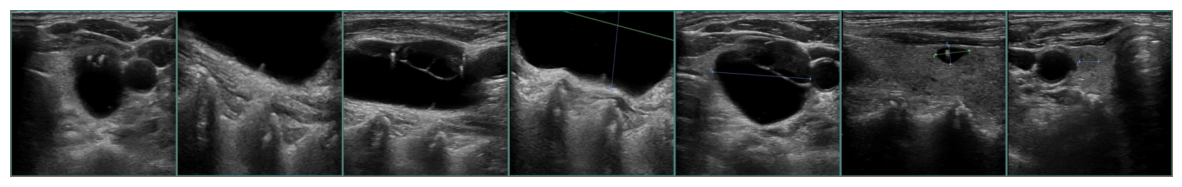

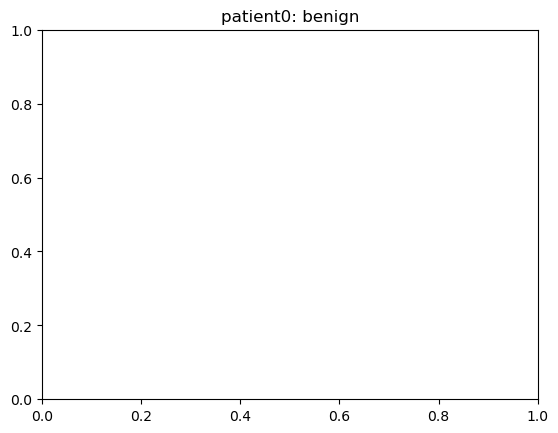

In [67]:
class_names = {0: "benign", 1: "malignant"}
image0, label0, patient0 = dataset[0]  # select images from patient0
# Make a grid from patient0
plt.figure(figsize=[15, 15])
out = torchvision.utils.make_grid(image0)
imshow(out, title="patient0" + ": " + class_names[label0], savename="magdemo.svg")

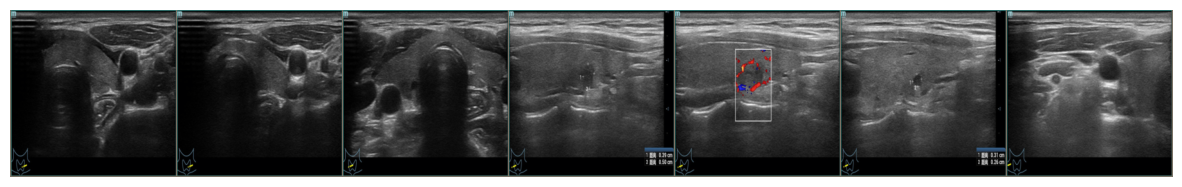

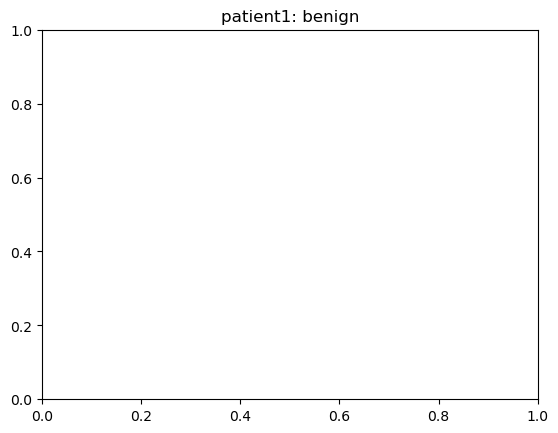

In [68]:
image1, label1, patient1 = dataset[1]  # select images from patient1
# Make a grid from patient1
plt.figure(figsize=[15, 15])
out = torchvision.utils.make_grid(image1)
imshow(out, title="patient1" + ": " + class_names[label1], savename="bedemo.svg")

In [69]:
"""Kiểm tra ảnh có tồn tại, đúng định dạng
Xem các góc chụp khác nhau của cùng 1 bệnh nhân
Đảm bảo ROI được đánh dấu đúng"""

'Kiểm tra ảnh có tồn tại, đúng định dạng\nXem các góc chụp khác nhau của cùng 1 bệnh nhân\nĐảm bảo ROI được đánh dấu đúng'

#### Build dataloader
Because each patient has various images, each item generated by the dataset is various in length.
In order to wrap it into dataloader, we need to pad each tensor in dataset to a fixed length.
We know that the max length is 31 in our data, thus we need to pad the length to 31

In [70]:
# build our own collate_fn
def pad_tensor(tensor, pad, dim):
    """
    tensor: tensor to pad
    pad: the size to pad to
    dim: dimension to pad
    """
    pad_size = list(tensor.shape)
    pad_size[dim] = pad - tensor.size(dim)
    return torch.cat([tensor, torch.zeros(pad_size)], dim=dim)


class PadCollate:
    """
    a variant of callate_fn that pads according to the longest sequence in
    a batch of sequences
    """

    def __init__(self, dim=0):
        """
        args:
            dim - the dimension to be padded (dimension of time in sequences)
        """
        self.dim = dim

    def pad_collate(self, batch):
        """
        args:
            batch - list of (tensor, label)

        reutrn:
            xs - a tensor of all examples in 'batch' after padding
            ys - a LongTensor of all labels in batch
        """
        # find longest sequence
        max_len = max(map(lambda x: x[0].shape[self.dim], batch))
        # pad according to max_len
        images = [x[0] for x in batch]
        labels = [x[1] for x in batch]
        patients = [x[2] for x in batch]
        batch = map(lambda x, y, z: [pad_tensor(x, pad=max_len, dim=self.dim), y, z], images, labels, patients)
        # stack all
        batch = list(batch)
        xs = torch.stack(list(map(lambda x: x[0], batch)), dim=0)
        ys = torch.LongTensor(list(map(lambda x: x[1], batch)))
        zs = list(map(lambda x: x[2], batch))
        return xs, ys, zs

    def __call__(self, batch):
        return self.pad_collate(batch)

In [71]:
"""Tự động pad theo batch → không cần biết trước max = 31
Tiết kiệm bộ nhớ hơn pad cố định 31
Thành công → Dữ liệu đã vào batch đúng định dạng!"""

'Tự động pad theo batch → không cần biết trước max = 31\nTiết kiệm bộ nhớ hơn pad cố định 31\nThành công → Dữ liệu đã vào batch đúng định dạng!'

In [72]:
dataloader = DataLoader(dataset, batch_size=16, shuffle=True, collate_fn=PadCollate(dim=0), num_workers=6)

In [73]:
x, y, z=iter(dataloader).__next__()  # check one batch of data

### Build model

ThyNet building, a dual attention and end-to-end model for thyroid diagnosis

#### Instance Relationship Attention Module (IRAM)
We propose IRAM to explore relationship across different images in a patient for instance feature enhancement.

$F=[F_1, F_2, ..., F_c], F\in\mathbb{R}^{(N\times K) \times C \times H \times W}$

$F_{ds}=f_{downsample}(F)$

$M_{IRAM}=$

In [74]:
"""Tăng cường mối quan hệ giữa các ảnh trong cùng 1 bệnh nhân
→ Ảnh nào có đặc trưng giống nhau → được tăng trọng số
Input: [B, K, 3, 256, 256] → ResNet34 → [B*K, C1, H, W]
       ↓
     IRAM → M (enhanced features)
       ↓
     ISAM → A (attention weights) + pooled features
       ↓
     Classifier → logits [B, 2]
"""

'Tăng cường mối quan hệ giữa các ảnh trong cùng 1 bệnh nhân\n→ Ảnh nào có đặc trưng giống nhau → được tăng trọng số\nInput: [B, K, 3, 256, 256] → ResNet34 → [B*K, C1, H, W]\n       ↓\n     IRAM → M (enhanced features)\n       ↓\n     ISAM → A (attention weights) + pooled features\n       ↓\n     Classifier → logits [B, 2]\n'

In [75]:
"""
IRAM
args:
    C1: channel of feature extracted by feature extractor, equals to C
    C2: channel C'
    dropout: whether to use dropout (p=0.25)
    tau: scaling factor for psi12
"""
class IRAM(nn.Module):
    
    def __init__(self, C1, C2=128, dropout=True, tau=128):
        super(IRAM, self).__init__()
        self.C1 = C1
        self.C2 = C2
        self.psi1 = [
            nn.Conv2d(C1, C2, kernel_size=(3, 3), padding=1),
            nn.ReLU()
        ]
        self.psi2 = [
            nn.Conv2d(C1, C2, kernel_size=(3, 3), padding=1),
            nn.ReLU()
        ]
        self.psi3 = [
            nn.Conv2d(C1, C2, kernel_size=(3, 3), padding=1),
            nn.ReLU()
        ]
        self.psi4 = [
            nn.Linear(C2, C1),
            nn.ReLU()
        ]
        if dropout:
            self.psi1.append(nn.Dropout(0.25))
            self.psi2.append(nn.Dropout(0.25))
            self.psi3.append(nn.Dropout(0.25))
            self.psi4.append(nn.Dropout(0.25))
        self.tau = tau
        self.psi1 = nn.Sequential(*self.psi1)
        self.psi2 = nn.Sequential(*self.psi2)
        self.psi3 = nn.Sequential(*self.psi3)
        self.psi4 = nn.Sequential(*self.psi4)
        
    def forward(self, x):
        x_psi1 = self.psi1(x)
        x_psi1 = x_psi1.view(-1, self.C2)
        x_ds = F.interpolate(x, scale_factor=0.5)
        x_psi2 = self.psi2(x_ds)
        x_psi2 = x_psi2.view(self.C2, -1)
        x_psi3 = self.psi3(x_ds)
        x_psi3 = x_psi3.view(-1, self.C2)
        psi12 = F.softmax(torch.mm(x_psi1, x_psi2) / self.tau)
        psi123 = torch.mm(psi12, x_psi3)
        psi1234 = self.psi4(psi123)
        M = psi1234.view(x.shape) + x
        return M, x

In [76]:
# check IRAM
x=torch.randn(16, 20, 256, 8, 8)
iram = IRAM(C1=256)
x_viewed = x.view(-1, 256, 8, 8)
M, x_out = iram(x_viewed)
print(M.shape)
print(x_out.shape)

torch.Size([320, 256, 8, 8])
torch.Size([320, 256, 8, 8])


/tmp/ipykernel_2967288/2454783762.py:50: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  psi12 = F.softmax(torch.mm(x_psi1, x_psi2) / self.tau)


#### Instance Score Attention Module (ISAM)
We propose ISAM to give importance score to different images in a patient for instance feature filtering.

In [77]:
"""
ISAM
args:
    batch_size: batch size
    L: input feature dimension of M, equals to C1 in IRAM module
    D: hidden layer dimension
    dropout: whether to use dropout (p=0.25)
    n_classes: number of classes
"""
class ISAM(nn.Module):
    
    def __init__(self, batch_size, L, D=256, n_classes=1, dropout=True):
        super(ISAM, self).__init__()
        self.L = L
        self.D = D
        self.batch_size = batch_size
        self.pool = nn.AdaptiveAvgPool2d((1, 1))
        self.attention_a = [
            nn.Linear(L, D),
            nn.Tanh()
        ]
        self.attention_b = [
            nn.Linear(L, D),
            nn.Sigmoid()
        ]
        if dropout:
            self.attention_a.append(nn.Dropout(0.25))
            self.attention_b.append(nn.Dropout(0.25))
            
        self.attention_a = nn.Sequential(*self.attention_a)
        self.attention_b = nn.Sequential(*self.attention_b)
        self.attention_c = nn.Linear(D, n_classes)
        
    def forward(self, x):
        x_pooled = self.pool(x).view(x.shape[0], self.L)
        a = self.attention_a(x_pooled)
        b = self.attention_b(x_pooled)
        A = a.mul(b)
        A = self.attention_c(A)
        if not self.training:
            A = A.view(1, 1, -1)
        else:
            A = A.view(self.batch_size, 1, -1)
        return A, x_pooled, x

In [78]:
# check ISAM
isam = ISAM(batch_size=16, L=M.shape[1])
A, x_pooled, x_out_isam = isam(M)

In [79]:
print(A.shape)
print(x_pooled.shape)
print(x_out_isam.shape)

torch.Size([16, 1, 20])
torch.Size([320, 256])
torch.Size([320, 256, 8, 8])


In [80]:
torch.equal(x_out_isam, M)

True

#### ThyNet model
Put all the modules together and build the final ThyNet model.

In [81]:
"""
Args:
    C2: channel C', default 128
    D: hidden layer dimension, default 256
    batch_size: batch_size
    num_cls: number of classes, default 2
    n_channels: image channel, 3 in this study
    dropout: whether to use dropout (p=0.25)
"""
class ThyNet(nn.Module):
    
    def __init__(self, C2, D, batch_size, dropout=True, num_cls=2, n_channels=3):
        super(ThyNet, self).__init__()
        feature_extractor = resnet34(pretrained=True)
        self.feature_extractor = nn.Sequential(*list(feature_extractor.children())[:-2])
        #for p in self.feature_extractor.parameters():
            #p.requires_grad = False
        self.C1 = self.feature_extractor[-1][-1].conv2.out_channels
        self.L = self.C1
        self.iram = IRAM(C1=self.C1, C2=C2, dropout=dropout, tau=C2)
        self.isam = ISAM(batch_size=batch_size, L=self.L, D=D, dropout=dropout)
        self.classifier = nn.Linear(self.C1, num_cls)
        
        self.n_channels = n_channels
        self.batch_size = batch_size
        
    def forward(self, x):
        ## 1. Flatten bệnh nhân → ảnh riêng lẻ
        x = x.view(-1, self.n_channels, x.shape[-2], x.shape[-1])
        # 2. Trích đặc trưng
        feat = self.feature_extractor(x)
        # 3. IRAM: Tăng cường quan hệ
        M, _ = self.iram(feat)
        # 4. ISAM: Tính trọng số A
        A, x_pooled, _ = self.isam(M)
        # 5. Softmax theo chiều ảnh (K)
        A = F.softmax(A, dim=2)  # softmax over instances
        # 6. Weighted sum các ảnh
        if not self.training:
            x_pooled = x_pooled.view(1, -1, self.C1)
            h = torch.bmm(A, x_pooled).view(1, self.C1)
        else:
            x_pooled = x_pooled.view(self.batch_size, -1, self.C1)
            h = torch.bmm(A, x_pooled).view(self.batch_size, self.C1)
        # 7. Phân loại
        logits = self.classifier(h)
        return logits

In [82]:
"""IRAM: "Các ảnh nào giống nhau → tăng cường đặc trưng"
ISAM: "Ảnh nào quan trọng nhất → gán trọng số cao"
ThyNet: Tổng hợp 1 bệnh nhân → 1 vector → phân loại"""

'IRAM: "Các ảnh nào giống nhau → tăng cường đặc trưng"\nISAM: "Ảnh nào quan trọng nhất → gán trọng số cao"\nThyNet: Tổng hợp 1 bệnh nhân → 1 vector → phân loại'

Insert model picture here
xxxxxxxxx

In [83]:
# Check ThyNet
demo_xs, demo_labels, demo_patients = iter(dataloader).__next__()
thynet = ThyNet(C2=128, D=256, batch_size=16)
thynet

/home/khanh247/.local/lib/python3.10/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/khanh247/.local/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet34_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet34_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


ThyNet(
  (feature_extractor): Sequential(
    (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (4): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_st

In [84]:
demo_preds = thynet(demo_xs)
print("demo_patients: ", demo_patients)
print("demo_labels: ", demo_labels.shape)
print(demo_labels)
print("===========\n")
print("demo_preds: ", demo_preds.shape)
print(demo_preds)

demo_patients:  [273, 292, 308, 387, 531, 374, 392, 513, 311, 233, 268, 584, 274, 509, 574, 208]
demo_labels:  torch.Size([16])
tensor([0, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0])

demo_preds:  torch.Size([16, 2])
tensor([[ 0.2633,  0.1999],
        [ 0.1234, -0.0867],
        [ 0.0167, -0.0268],
        [ 0.1629,  0.1294],
        [ 0.3186, -0.0828],
        [-0.0934,  0.3059],
        [ 0.0448,  0.1279],
        [-0.1820,  0.0832],
        [-0.1452, -0.0111],
        [ 0.0380,  0.0545],
        [-0.0185,  0.1779],
        [ 0.3155,  0.1173],
        [-0.2106,  0.0650],
        [ 0.2867,  0.3370],
        [-0.0219,  0.0348],
        [ 0.0019, -0.0357]], grad_fn=<AddmmBackward0>)


/tmp/ipykernel_2967288/2454783762.py:50: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  psi12 = F.softmax(torch.mm(x_psi1, x_psi2) / self.tau)


### Training procedure

#### Create 5-fold cross validation set
First, split all patients into trainval and test, then split trainval patients into 5 fold. Save all the csv files in ./split folder.

In [85]:
"""
Args:
    csv1_path: image_paths.csv in ./tmp folder
    csv2_path: patient_name_label.csv in ./tmp folder
    test_size: size of test set for external testing
    seed: random seed
    k: number of folds
    split_dir: dir to save splitted csv files, default ./split folder
"""
def split(csv1_path, csv2_path, test_size=0.1, seed=202203, k=5, split_dir="./split"):
    print("Splitting %d fold csv files..." % k)
    os.makedirs(split_dir, exist_ok=True)
    # 1. Đọc dữ liệu
    all_image_paths_df = pd.read_csv(csv1_path)
    all_patient_and_labels_df = pd.read_csv(csv2_path)
    # 2. Chia test set (10%)
    train_val_patient_df, test_patient_df = train_test_split(all_patient_and_labels_df,
                                                             test_size=test_size,
                                                             random_state=seed)
    print("Saving patient level test df")
    test_patient_df.to_csv(os.path.join(split_dir, "test_case.csv"), index=False)
    test_images_paths_df = all_image_paths_df[
        all_image_paths_df["patient_name"].isin(test_patient_df["patient_name"])
    ]
    print("Saving image level test df")
    test_images_paths_df.to_csv(os.path.join(split_dir, "test_image.csv"), index=False)
    # 3. Chia 5-fold train/val
    kf = KFold(n_splits=k, random_state=seed, shuffle=True)
    for i, (train_index, test_index) in enumerate(kf.split(train_val_patient_df)):
        train_patient_df, val_patient_df = train_val_patient_df.iloc[train_index], train_val_patient_df.iloc[test_index]
        print("Saving patient level df fold %d" % i)
        train_patient_df.to_csv(os.path.join(split_dir, "train_case_split_" + str(i) + ".csv"), index=False)
        val_patient_df.to_csv(os.path.join(split_dir, "val_case_split_" + str(i) + ".csv"), index=False)
        train_image_paths_df = all_image_paths_df[
            all_image_paths_df["patient_name"].isin(train_patient_df["patient_name"])
        ]
        val_image_paths_df = all_image_paths_df[
            all_image_paths_df["patient_name"].isin(val_patient_df["patient_name"])
        ]
        print("Saving image level df fold %d" % i)
        train_image_paths_df.to_csv(os.path.join(split_dir, "train_image_split_" + str(i) + ".csv"), index=False)
        val_image_paths_df.to_csv(os.path.join(split_dir, "val_image_split_" + str(i) + ".csv"), index=False)

In [86]:
csv1_path = "./data/batch1_image/filtered_images.csv"
csv2_path = "./data/batch1_image/batch1_image_label.csv"
split(csv1_path, csv2_path)

Splitting 5 fold csv files...
Saving patient level test df
Saving image level test df
Saving patient level df fold 0
Saving image level df fold 0
Saving patient level df fold 1
Saving image level df fold 1
Saving patient level df fold 2
Saving image level df fold 2
Saving patient level df fold 3
Saving image level df fold 3
Saving patient level df fold 4
Saving image level df fold 4


#### Some tools for training

In [87]:
"""
Learning rate warming up
"""
def warmup_lr_scheduler(optimizer, warmup_iters, warmup_factor):
    """learning rate warmup"""

    def f(x):
        if x >= warmup_iters:
            return 1
        alpha = float(x) / warmup_iters
        return warmup_factor * (1 - alpha) + alpha
    return torch.optim.lr_scheduler.LambdaLR(optimizer, f)

In [88]:
@torch.no_grad()
def eval_process(epoch, model, criterion, dataloader, device):
    print("Epoch %d Validation......" % epoch)
    cpu_device = torch.device("cpu")
    model.eval()
    labels = []
    preds = []
    running_loss = 0.
    for images, targets, _ in tqdm(dataloader):
        images = images.to(device)
        labels.extend(targets.tolist())
        targets = targets.to(device)
        logits = model(images)
        preds.extend(logits.cpu().numpy()[:, -1].tolist())
        loss = criterion(logits, targets)
        running_loss += loss.item() * images.size(0)

    eval_loss = running_loss / len(dataloader.dataset)
    print("Eval val loss: %.4f" % eval_loss)
    
    auc_score = roc_auc_score(labels, preds)
    print("Val AUC: %.4f" % auc_score)
    return auc_score, eval_loss

In [89]:
@torch.no_grad()
def test_process(model, criterion, dataloader, device):
    cpu_device = torch.device("cpu")
    model.eval()
    labels = []
    preds_logits = []
    preds_probs = []
    running_loss = 0.
    all_patient_names = []
    for ind, (images, targets, patient_names) in enumerate(tqdm(dataloader)):
        images = images.to(device)
        labels.extend(targets.tolist())
        targets = targets.to(device)
        logits = model(images)
        pred_probs = torch.softmax(logits, 1)
        preds_probs.extend(pred_probs.cpu().numpy()[:, -1].tolist())
        loss = criterion(logits, targets)
        running_loss += loss.item() * images.size(0)
        all_patient_names.extend(patient_names)
        preds_logits.extend(logits.cpu().numpy()[:, -1].tolist())

    test_loss = running_loss / len(dataloader.dataset)
    print("Test loss: %.4f" % test_loss)
    
    auc_score = roc_auc_score(labels, preds_logits)
    average_precision = average_precision_score(labels, preds_logits)
    print("Test AUC: %.4f" % auc_score)
    print("Test AP: %.4f" % average_precision)
    # plot_roc_curve(labels, final_logits)
    # plot_pr_curve(labels, final_logits)
    df = pd.DataFrame({"patient_name": all_patient_names,
                       "prob": preds_probs,
                       "logit": preds_logits,
                       "label": labels})

    return auc_score, test_loss, df

In [90]:
def train_process(model, criterion, optimizer, lr_sche, dataloaders,
                  num_epochs, use_tensorboard, device,
                  save_model_path, record_iter, writer=None):
    model.train()

    best_score = 0.0
    best_state_dict = copy.deepcopy(model.state_dict())

    for epoch in range(num_epochs):
        lr_scheduler = None
        running_loss = 0.0
        print("====Epoch{0}====".format(epoch))
        if epoch == 0:
            warmup_factor = 1. / 1000
            warmup_iters = min(1000, len(dataloaders["train"]) - 1)
            lr_scheduler = warmup_lr_scheduler(
                optimizer, warmup_iters, warmup_factor
            )

        for i, (images, targets, _) in enumerate(tqdm(dataloaders["train"])):
            images = images.to(device)
            targets = targets.to(device)
            optimizer.zero_grad()
            logits = model(images)
            loss = criterion(logits, targets)

            if not math.isfinite(loss.item()):
                print("Loss is {}, stopping training".format(loss.item()))
                sys.exit(1)

            loss.backward()
            optimizer.step()
            if lr_scheduler is not None:
                lr_scheduler.step()

            running_loss += loss.item() * images.size(0)

            lr = optimizer.param_groups[0]["lr"]

            if (i + 1) % record_iter == 0:
                to_date_cases = (i + 1) * images.size(0)
                tmp_loss = running_loss / to_date_cases
                print("Epoch{0} loss:{1:.4f}".format(epoch, tmp_loss))
                
                if use_tensorboard:
                    writer.add_scalar("Train loss",
                                      tmp_loss,
                                      epoch * len(dataloaders["train"]) + i)
                    writer.add_scalar("lr", lr,
                                      epoch * len(dataloaders["train"]) + i)

        val_auc, val_loss = eval_process(
            epoch, model, criterion, dataloaders["val"], device
        )
        if lr_sche is not None:
            lr_sche.step()

        if val_auc > best_score:
            best_score = val_auc
            best_state_dict = copy.deepcopy(model.state_dict())

        if use_tensorboard:
            writer.add_scalar(
                "validataion AUC", val_auc, global_step=epoch
            )
            writer.add_scalar(
                "validation loss", val_loss, global_step=epoch
            )

        model.train()

    print("Training Done!")
    print("Best Valid AUC: %.4f" % best_score)
    torch.save(best_state_dict, save_model_path)

    print("========Start Testing========")
    model.load_state_dict(best_state_dict)
    test_auc, test_loss, df = test_process(
        model, criterion, dataloaders["test"], device
    )
    if use_tensorboard:
        writer.add_scalar("Test AUC", test_auc, global_step=0)
        writer.close()

#### Training

##### Data augmentation

In [91]:
import torch
import numpy as np
from torch import nn

class Cutout(object):
    def __init__(self, n_holes, length):
        self.n_holes = n_holes
        self.length = length

    def __call__(self, img):
        """
        img: Tensor (C, H, W)
        """
        h = img.size(1)
        w = img.size(2)

        mask = np.ones((h, w), np.float32)

        for n in range(self.n_holes):
            y = np.random.randint(h)
            x = np.random.randint(w)

            y1 = np.clip(y - self.length // 2, 0, h)
            y2 = np.clip(y + self.length // 2, 0, h)
            x1 = np.clip(x - self.length // 2, 0, w)
            x2 = np.clip(x + self.length // 2, 0, w)

            mask[y1: y2, x1: x2] = 0.

        mask = torch.from_numpy(mask)
        mask = mask.expand_as(img)
        img = img * mask

        return img

In [92]:
"""Xóa ngẫu nhiên vùng ảnh → buộc model học đặc trưng toàn cục
Tăng khả năng tổng quát"""

'Xóa ngẫu nhiên vùng ảnh → buộc model học đặc trưng toàn cục\nTăng khả năng tổng quát'

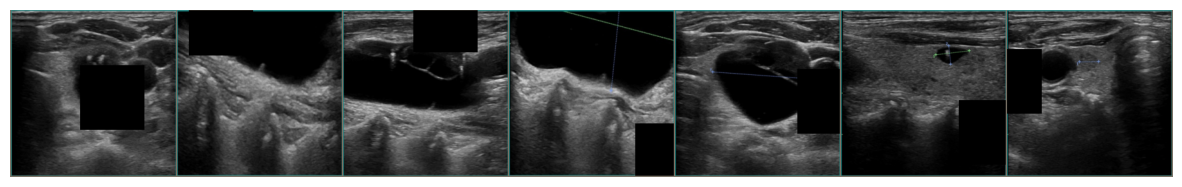

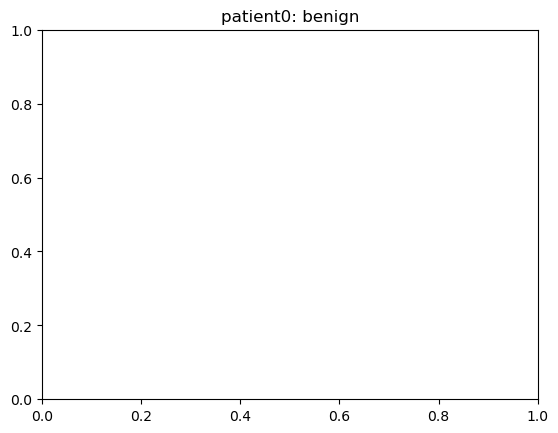

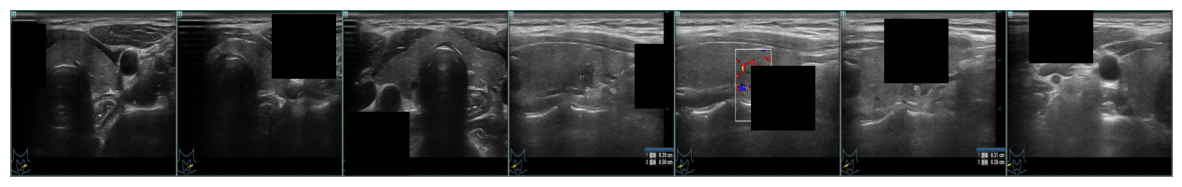

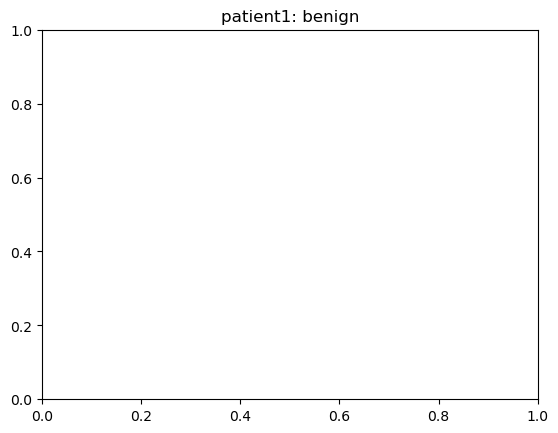

In [93]:
# Check Cutout
transform = transforms.Compose([
        transforms.Resize((256, 256)),
        transforms.ToTensor(),
        Cutout(1, 100),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ])

csv1_path = "/home/khanh247/Documents/Thac_si/Paper/deep_learning/ThyUS2Path/data/batch1_image/filtered_images.csv"
csv2_path = "/home/khanh247/Documents/Thac_si/Paper/deep_learning/ThyUS2Path/data/batch1_image/batch1_image_label.csv"
dataset = ThyDataset(csv1_path=csv1_path, csv2_path=csv2_path, transform=transform)

class_names = {0: "benign", 1: "malignant"}
image0, label0, patient0 = dataset[0]  # select images from patient0
# Make a grid from patient0
plt.figure(figsize=[15, 15])
out = torchvision.utils.make_grid(image0)
imshow(out, title="patient0" + ": " + class_names[label0])

image1, label1, patient1 = dataset[1]  # select images from patient0
# Make a grid from patient0
plt.figure(figsize=[15, 15])
out = torchvision.utils.make_grid(image1)
imshow(out, title="patient1" + ": " + class_names[label1])

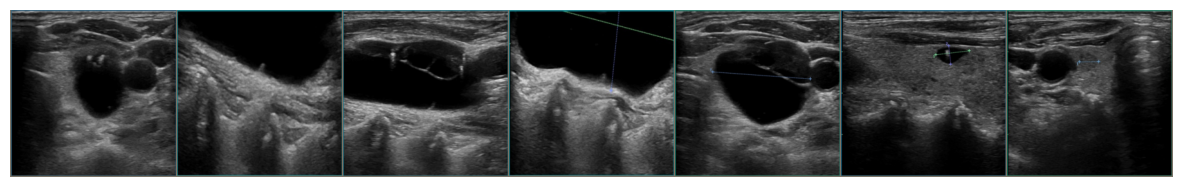

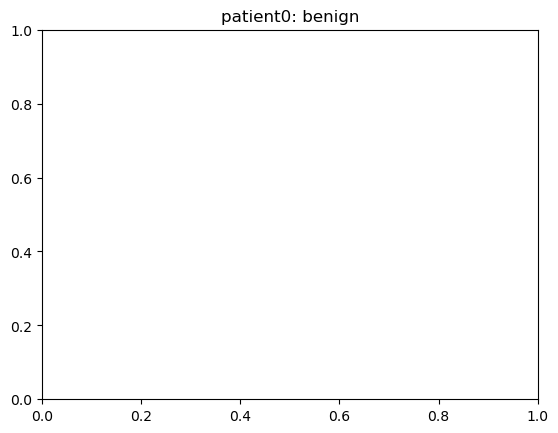

In [94]:
# Check Colorjitter
transform = transforms.Compose([
        transforms.Resize((256, 256)),
        transforms.ColorJitter(brightness=0.075, saturation=0.075, hue=0.075),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ])

csv1_path = "./data/batch1_image/filtered_images.csv"
csv2_path = "./data/batch1_image/batch1_image_label.csv"
dataset = ThyDataset(csv1_path=csv1_path, csv2_path=csv2_path, transform=transform)

class_names = {0: "benign", 1: "malignant"}
image0, label0, patient0 = dataset[0]  # select images from patient0
# Make a grid from patient0
plt.figure(figsize=[15, 15])
out = torchvision.utils.make_grid(image0)
imshow(out, title="patient0" + ": " + class_names[label0])

In [95]:
"""
RandomRotation
"""
class MyRotationTrans:
    def __init__(self, angles):
        self.angles = angles

    def __call__(self, x):
        angle = random.choice(self.angles)
        return torchvision.transforms.functional.rotate(x, angle)

In [96]:
# Build the final transform
transform = transforms.Compose([
        transforms.Resize((256, 256)),
        transforms.RandomHorizontalFlip(p=0.5),
        MyRotationTrans([0, 90, 180, 270]),
        transforms.ColorJitter(),
        #transforms.RandomVerticalFlip(),
        transforms.ToTensor(),
        Cutout(1, 100),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ])

val_transform = transforms.Compose([
        transforms.Resize((256, 256)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])

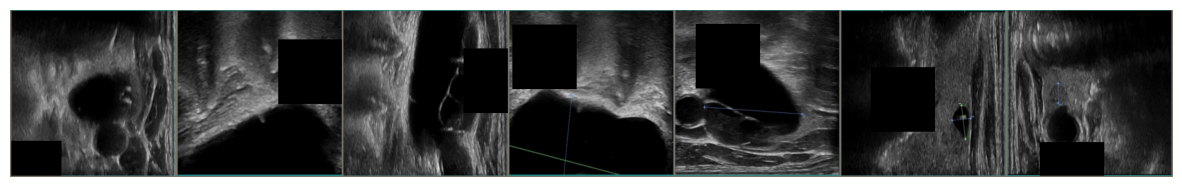

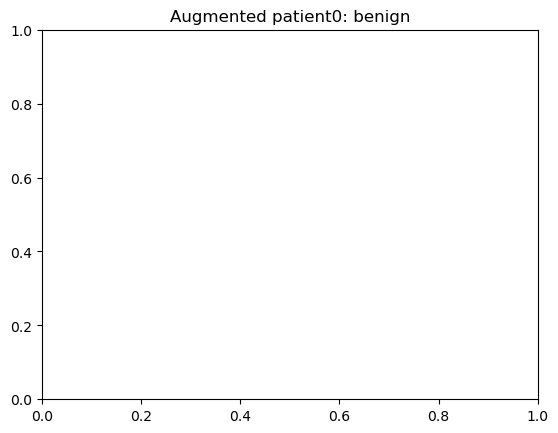

In [97]:
# Check train transform
csv1_path = "./data/batch1_image/filtered_images.csv"
csv2_path = "./data/batch1_image/batch1_image_label.csv"
dataset = ThyDataset(csv1_path=csv1_path, csv2_path=csv2_path, transform=transform)

class_names = {0: "benign", 1: "malignant"}
image0, label0, patient0 = dataset[0]  # select images from patient0
# Make a grid from patient0
plt.figure(figsize=[15, 15])
out = torchvision.utils.make_grid(image0)
imshow(out, title="Augmented patient0" + ": " + class_names[label0])

##### Training function

In [98]:
from torch.utils.data import Dataset
from PIL import Image
import torch

class ThyDatasetWith4Fold(Dataset):
    def __init__(self, df_images, df_labels, transform=None):
        self.df_images = df_images.reset_index(drop=True)
        self.df_labels = df_labels
        self.transform = transform
        
        # Sắp xếp patient theo thứ tự xuất hiện
        self.unique_patients = self.df_images['patient_name'].unique()
        self.unique_patients = sorted(self.unique_patients,
            key=lambda x: self.df_images[self.df_images['patient_name'] == x].index[0])

    def __len__(self):
        return len(self.unique_patients)

    def __getitem__(self, idx):
        patient = self.unique_patients[idx]
        label = int(self.df_labels[self.df_labels['patient_name'] == patient]['histo_label'].values[0])
        
        # Lấy full path trực tiếp từ cột 'path'
        image_paths = self.df_images[self.df_images['patient_name'] == patient]['path'].tolist()
        images = []
        for full_path in image_paths:
            img = Image.open(full_path).convert('RGB')  # full_path → không cần root_dir
            if self.transform:
                img = self.transform(img)
            images.append(img)
        
        return torch.stack(images), label, patient

In [99]:
def train_thynet(k, split_dir, save_model_dir,
                 train_trans, val_trans, batch_size,
                 num_workers, C2, D, device, lr,
                 momentum, weight_decay, gamma,
                 logdir, num_epochs, use_tensorboard,
                 record_iter):
    
    # ĐƯỜNG DẪN MỚI - CHỈ DÙNG 2 FILE
    filtered_csv = "/home/khanh247/Documents/Thac_si/Paper/deep_learning/ThyUS2Path/data/batch1_image/filtered_images.csv"
    label_csv = "/home/khanh247/Documents/Thac_si/Paper/deep_learning/ThyUS2Path/data/batch1_image/batch1_image_label.csv"
    
    # Load dữ liệu chung
    df_images = pd.read_csv(filtered_csv)  # có patient_name + path (full_path)
    df_labels = pd.read_csv(label_csv)     # có patient_name + histo_label
    
    # Đảm bảo patient_name là str
    df_images['patient_name'] = df_images['patient_name'].astype(str)
    df_labels['patient_name'] = df_labels['patient_name'].astype(str)
    
    # Test set (nếu có)
    test_patients = pd.read_csv(os.path.join(split_dir, "test_case.csv"))['patient_name'].astype(str).tolist()
    test_dataset = ThyDatasetWith4Fold(
        df_images=df_images[df_images['patient_name'].isin(test_patients)],
        df_labels=df_labels,
        transform=val_trans
    )
    test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False, num_workers=num_workers)
    
    # === K-FOLD LOOP ===
    for i in range(k):
        print(f"====Starting Fold {i + 1}====")
        
        # Đọc danh sách patient train/val từ split_dir
        train_patients = pd.read_csv(os.path.join(split_dir, f"train_case_split_{i}.csv"))['patient_name'].astype(str).tolist()
        val_patients = pd.read_csv(os.path.join(split_dir, f"val_case_split_{i}.csv"))['patient_name'].astype(str).tolist()
        
        # Tạo dataset từ filtered_images.csv
        train_dataset = ThyDatasetWith4Fold(
            df_images=df_images[df_images['patient_name'].isin(train_patients)],
            df_labels=df_labels,
            transform=train_trans
        )
        val_dataset = ThyDatasetWith4Fold(
            df_images=df_images[df_images['patient_name'].isin(val_patients)],
            df_labels=df_labels,
            transform=val_trans
        )
        
        # DataLoader
        train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True,
                                  collate_fn=PadCollate(dim=0), num_workers=num_workers, drop_last=True)
        val_loader = DataLoader(val_dataset, batch_size=1, shuffle=False, num_workers=num_workers)
        dataloaders = {"train": train_loader, "val": val_loader, "test": test_loader}
        
        print("Dataset Done...")
        
        # Model, optimizer, scheduler...
        thynet = ThyNet(C2=C2, D=D, batch_size=batch_size).to(device)
        params = [p for p in thynet.parameters() if p.requires_grad]
        optimizer = torch.optim.SGD(params, lr=lr, momentum=momentum, weight_decay=weight_decay)
        lr_scheduler = torch.optim.lr_scheduler.MultiStepLR(optimizer, milestones=[50, 75], gamma=gamma)
        criterion = nn.CrossEntropyLoss()
        
        writer = SummaryWriter(logdir)
        save_model_path = os.path.join(save_model_dir, f"thynet_fold_{i + 1}.pth")
        
        train_process(model=thynet, criterion=criterion, optimizer=optimizer,
                      lr_sche=lr_scheduler, dataloaders=dataloaders, writer=writer,
                      num_epochs=num_epochs, use_tensorboard=use_tensorboard,
                      device=device, save_model_path=save_model_path,
                      record_iter=record_iter)
    
    print("====Training Done====")

##### Training

In [100]:
# settings
k = 5
split_dir = "./split/"
save_model_dir = "./result/"
train_trans = transform
val_trans = val_transform
batch_size = 5
num_workers = 12
C2 = 128
D = 256
device = device
lr = 0.001
momentum = 0.9
weight_decay = 5e-4
gamma = 0.1
logdir = "./logs/"
num_epochs = 100
use_tensorboard = True
record_iter = 10

In [101]:
import torch, gc
gc.collect()
torch.cuda.empty_cache()


train_thynet(k, split_dir, save_model_dir,
             train_trans, val_trans, batch_size,
             num_workers, C2, D, device, lr,
             momentum, weight_decay, gamma,
             logdir, num_epochs, use_tensorboard,
             record_iter)

====Starting Fold 1====
Dataset Done...


/home/khanh247/.local/lib/python3.10/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/khanh247/.local/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet34_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet34_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


====Epoch0====


  0%|          | 0/71 [00:00<?, ?it/s]

/tmp/ipykernel_2967288/2454783762.py:50: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  psi12 = F.softmax(torch.mm(x_psi1, x_psi2) / self.tau)


...

  0%|          | 0/87 [00:00<?, ?it/s]

Eval val loss: 1.8670
Val AUC: 0.5023
Training Done!
Best Valid AUC: 0.6136
========Start Testing========


  0%|          | 0/53 [00:00<?, ?it/s]

/tmp/ipykernel_2967288/2454783762.py:50: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  psi12 = F.softmax(torch.mm(x_psi1, x_psi2) / self.tau)


Test loss: 0.9304
Test AUC: 0.5048
Test AP: 0.6882
====Training Done====


##### Test

In [102]:
model_path = "./result/thynet_fold_5.pth"
thynet = ThyNet(C2=C2, D=D, batch_size=1)
thynet = thynet.to(device)
thynet.load_state_dict(torch.load(model_path))
criterion = nn.CrossEntropyLoss()
test_dataset = ThyDataset(csv1_path="./split/test_image.csv", csv2_path="./split/test_case.csv",
                          transform=val_trans)
test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False,
                         num_workers=num_workers)
test_auc, test_loss, df = test_process(
    thynet, criterion, test_loader, device
)

/home/khanh247/.local/lib/python3.10/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/khanh247/.local/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet34_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet34_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


  0%|          | 0/53 [00:00<?, ?it/s]

/tmp/ipykernel_2967288/2454783762.py:50: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  psi12 = F.softmax(torch.mm(x_psi1, x_psi2) / self.tau)


Test loss: 0.9304
Test AUC: 0.5048
Test AP: 0.6882


In [103]:
df

,patient_name,prob,logit,label
0,tensor(341),0.980272,2.194179,0
1,tensor(261),0.779567,0.650418,1
2,tensor(41),0.938375,1.583325,1
3,tensor(321),0.468463,0.269553,1
4,tensor(88),0.943644,1.343093,1
5,tensor(68),0.163731,-0.289214,0
6,tensor(408),0.965923,1.936462,0
7,tensor(162),0.512687,0.256252,0
8,tensor(49),0.688203,0.674074,0
9,tensor(164),0.742838,0.529387,1


## Another way: interative sampling instances

### Build dataset

In [104]:
def sample_func(image_paths_list, N=10):
    if len(image_paths_list) >= 10:
        res = list(np.random.choice(image_paths_list, N, replace=False))
    else:
        res = list(np.random.choice(image_paths_list, N, replace=True))
    return res

In [105]:
class ThyDataset2(Dataset):
    
    def __init__(self, csv1_path, csv2_path, transform=None, N=10):
        """
        csv1_path: image_paths.csv in ./tmp folder
        csv2_path: patient_name_label.csv in ./tmp folder
        """
        self.df = pd.read_csv(csv1_path)
        self.unique_patients = list(set(self.df.patient_name))
        self.unique_patients.sort(key=list(self.df.patient_name).index)
        self.ref_df = pd.read_csv(csv2_path)
        self.transform = transform
        self.patient = None
        self.N = N
        
    def __len__(self):
        return len(self.unique_patients)
    
    def __getitem__(self, index):
        images = []
        self.patient = self.unique_patients[index]
        label = self.ref_df[self.ref_df['patient_name']== self.patient].histo_label.item()
        image_paths_of_this_patient = list(self.df.path[self.df.patient_name == self.patient])
        image_paths_of_this_patient = sample_func(image_paths_of_this_patient, self.N)
        for image_path in image_paths_of_this_patient:
            image = Image.open(image_path)
            if self.transform is not None:
                image = self.transform(image)
            images.append(image)
        images = torch.stack(images, dim=0)
        return images, label, self.patient

In [111]:
# Check dataset
transform = transforms.Compose([
    transforms.Resize([256, 256]),
    transforms.RandomRotation(15),
    transforms.ColorJitter(),
    transforms.RandomCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])
csv1_path = "./data/batch1_image/filtered_images.csv"
csv2_path = "./data/batch1_image/batch1_image_label.csv"
dataset = ThyDataset2(csv1_path=csv1_path, csv2_path=csv2_path, transform=transform, N=10)

In [112]:
image0, label0, patient0 = dataset[0]
print("Patient0 info: %s" % patient0)
print("Patient0 images shape: ", image0.shape)
print("Patient0 label: ", label0)
print("=====================")
image1, label1, patient1 = dataset[1]
print("Patient1 info: %s" % patient1)
print("Patient1 images shape: ", image1.shape)
print("Patient1 label: ", label1)

Patient0 info: 341
Patient0 images shape:  torch.Size([10, 3, 224, 224])
Patient0 label:  0
Patient1 info: 92
Patient1 images shape:  torch.Size([10, 3, 224, 224])
Patient1 label:  0


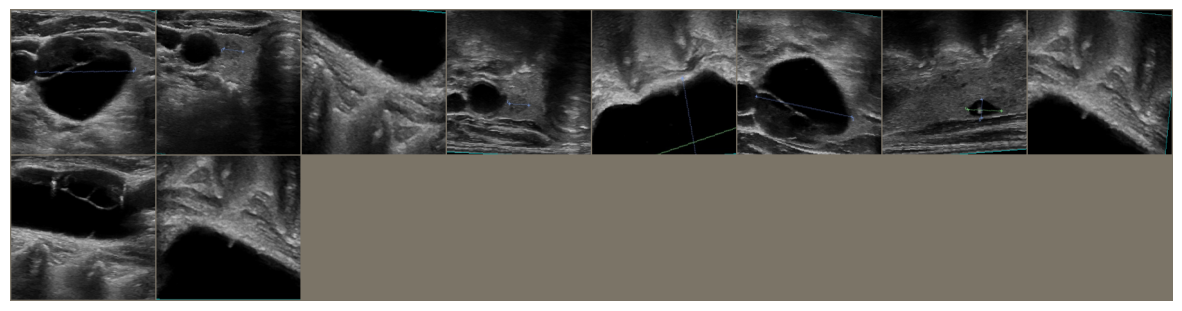

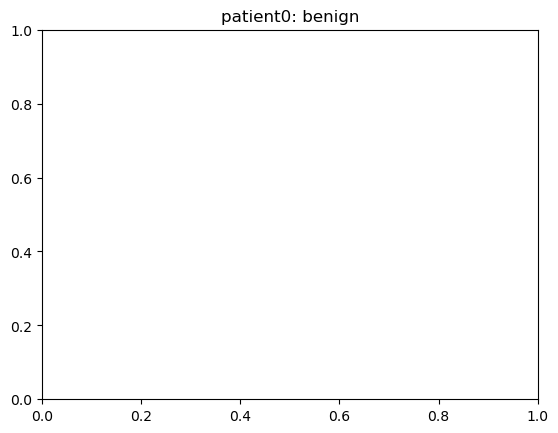

In [113]:
class_names = {0: "benign", 1: "malignant"}
image0, label0, patient0 = dataset[0]  # select images from patient0
# Make a grid from patient0
plt.figure(figsize=[15, 15])
out = torchvision.utils.make_grid(image0)
imshow(out, title="patient0" + ": " + class_names[label0])

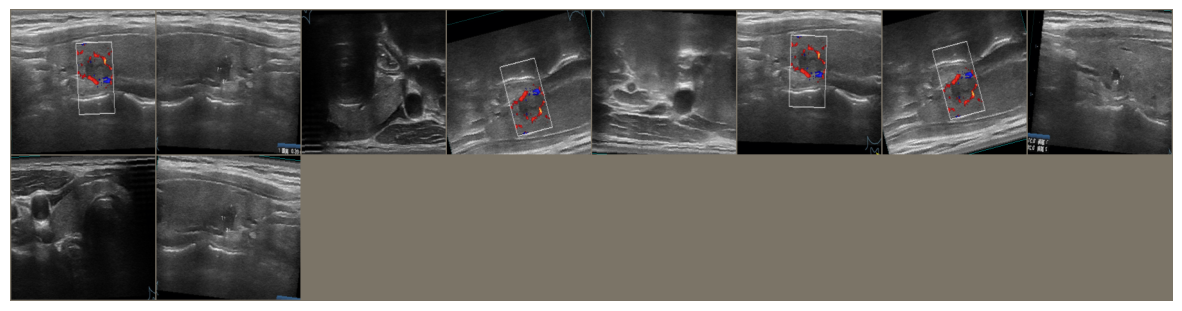

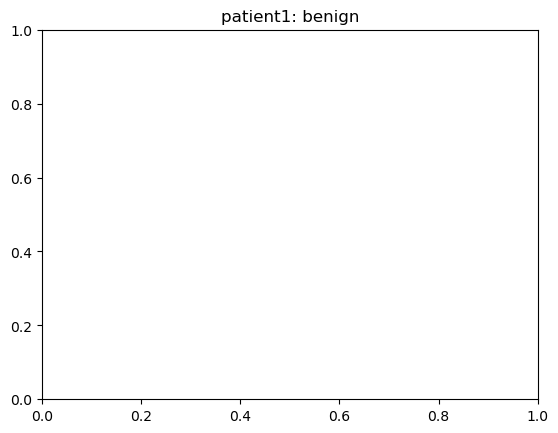

In [114]:
class_names = {0: "benign", 1: "malignant"}
image1, label1, patient1 = dataset[1]  # select images from patient0
# Make a grid from patient1
plt.figure(figsize=[15, 15])
out = torchvision.utils.make_grid(image1)
imshow(out, title="patient1" + ": " + class_names[label1])

In [115]:
# Check dataloader
dataloader = DataLoader(dataset, batch_size=8, shuffle=True, num_workers=6)
x, y, z=iter(dataloader).__next__()  # check one batch of data
print("x shape: ", x.shape)
print("y: ", y)
print("z: ", z)

x shape:  torch.Size([8, 10, 3, 224, 224])
y:  tensor([0, 1, 0, 1, 1, 1, 1, 1])
z:  tensor([ 27, 198, 322, 554, 480,  93, 381, 223])


In [116]:
for i in tqdm(dataloader):
    continue

  0%|          | 0/62 [00:00<?, ?it/s]

In [117]:
@torch.no_grad()
def eval_process(epoch, model, criterion, dataloader, device, num_bags=5,
                 aggregate="max"):
    assert aggregate == "mean" or aggregate == "max", "aggregate must be mean or max"
    print("Epoch %d Validation......" % epoch)
    cpu_device = torch.device("cpu")
    model.eval()
    preds_pool = []
    running_loss_pool = []
    for i in range(num_bags):
        print("sampling the %d bag......" % (i+1))
        preds = []
        labels = []
        running_loss = 0.
        for images, targets, _ in tqdm(dataloader):
            images = images.to(device)
            labels.extend(targets.numpy().tolist())
            targets = targets.to(device)
            logits = model(images)
            preds.extend(logits.cpu().numpy()[:, -1].tolist())
            loss = criterion(logits, targets)
            running_loss += loss.item() * images.size(0)

        preds_pool.append(preds)
        this_bag_loss = running_loss / len(dataloader.dataset)
        running_loss_pool.append(this_bag_loss)
        print("bag val loss: %.4f" % this_bag_loss)
    
    final_loss_mean = np.mean(running_loss_pool)
    print("Val loss: %.4f" % final_loss_mean)
    preds_pool_array = np.stack(preds_pool)
    if aggregate == "mean":
        final_logits = np.mean(preds_pool_array, axis=0)
    elif aggregate == "max":
        final_logits = np.max(preds_pool_array, axis=0)
    auc_score = roc_auc_score(labels, final_logits)
    print("Val AUC: %.4f" % auc_score)
    return auc_score, final_loss_mean

In [118]:
@torch.no_grad()
def test_process(model, criterion, dataloader, device, num_bags=5,
                 aggregate="max"):
    assert aggregate == "mean" or aggregate == "max", "aggregate must be mean or max"
    cpu_device = torch.device("cpu")
    model.eval()
    preds_pool = []
    preds_probs_pool = []
    running_loss_pool = []
    all_slide_names = []
    for i in range(num_bags):
        print("sampling the %d bag......" % (i+1))
        preds = []
        preds_probs = []
        labels = []
        running_loss = 0.
        try:
            for ind, (images, targets, patient_names) in enumerate(tqdm(dataloader)):
                images = images.to(device)
                labels.extend(targets.numpy().tolist())
                targets = targets.to(device)
                logits = model(images)
                pred_probs = torch.softmax(logits, 1)
                preds_probs.extend(pred_probs.cpu().numpy()[:, -1].tolist())
                preds.extend(logits.cpu().numpy()[:, -1].tolist())
                loss = criterion(logits, targets)
                running_loss += loss.item() * images.size(0)
                if i == 0:
                    all_slide_names.extend(patient_names)
        except RuntimeError:
            print("RuntimeError")
            print(slide_names)
            import ipdb;ipdb.set_trace()
            break
        except TypeError:
            print(patient_names)
            print("TypeError")
            import ipdb;ipdb.set_trace()
            break

        preds_pool.append(preds)
        preds_probs_pool.append(preds_probs)
        this_bag_loss = running_loss / len(dataloader.dataset)
        running_loss_pool.append(this_bag_loss)
        print("bag test loss: %.4f" % this_bag_loss)
    
    final_loss_mean = np.mean(running_loss_pool)
    print("Test loss: %.4f" % final_loss_mean)
    preds_pool_array = np.stack(preds_pool)
    preds_probs_pool_array = np.stack(preds_probs_pool)
    if aggregate == "mean":
        final_logits = np.mean(preds_pool_array, axis=0)
        final_probs = np.mean(preds_probs_pool_array, axis=0)
    elif aggregate == "max":
        final_logits = np.max(preds_pool_array, axis=0)
        final_probs = np.max(preds_probs_pool_array, axis=0)
    auc_score = roc_auc_score(labels, final_logits)
    average_precision = average_precision_score(labels, final_logits)
    print("Test AUC: %.4f" % auc_score)
    print("Test AP: %.4f" % average_precision)
    # plot_roc_curve(labels, final_logits)
    # plot_pr_curve(labels, final_logits)
    df = pd.DataFrame({"slide_name": all_slide_names,
                       "prob": final_probs,
                       "logit": final_logits,
                       "label": labels})

    return auc_score, final_loss_mean, df

In [119]:
def train_process(model, criterion, optimizer, lr_sche, dataloaders,
                  num_epochs, use_tensorboard, device,
                  save_model_path, record_iter, writer=None):
    model.train()

    best_score = 0.0
    best_state_dict = copy.deepcopy(model.state_dict())

    for epoch in range(num_epochs):
        lr_scheduler = None
        running_loss = 0.0
        print("====Epoch{0}====".format(epoch))
        if epoch == 0:
            warmup_factor = 1. / 1000
            warmup_iters = min(1000, len(dataloaders["train"]) - 1)
            lr_scheduler = warmup_lr_scheduler(
                optimizer, warmup_iters, warmup_factor
            )

        for i, (images, targets, _) in enumerate(tqdm(dataloaders["train"])):
            images = images.to(device)
            targets = targets.to(device)
            optimizer.zero_grad()
            logits = model(images)
            loss = criterion(logits, targets)

            if not math.isfinite(loss.item()):
                print("Loss is {}, stopping training".format(loss.item()))
                sys.exit(1)

            loss.backward()
            optimizer.step()
            if lr_scheduler is not None:
                lr_scheduler.step()

            running_loss += loss.item() * images.size(0)

            lr = optimizer.param_groups[0]["lr"]

            if (i + 1) % record_iter == 0:
                to_date_cases = (i + 1) * images.size(0)
                tmp_loss = running_loss / to_date_cases
                print("Epoch{0} loss:{1:.4f}".format(epoch, tmp_loss))
                
                if use_tensorboard:
                    writer.add_scalar("Train loss",
                                      tmp_loss,
                                      epoch * len(dataloaders["train"]) + i)
                    writer.add_scalar("lr", lr,
                                      epoch * len(dataloaders["train"]) + i)

        val_auc, val_loss = eval_process(
            epoch, model, criterion, dataloaders["val"], device
        )
        if lr_sche is not None:
            lr_sche.step()

        if val_auc > best_score:
            best_score = val_auc
            best_state_dict = copy.deepcopy(model.state_dict())

        if use_tensorboard:
            writer.add_scalar(
                "validataion AUC", val_auc, global_step=epoch
            )
            writer.add_scalar(
                "validation loss", val_loss, global_step=epoch
            )

        model.train()

    print("Training Done!")
    print("Best Valid AUC: %.4f" % best_score)
    torch.save(best_state_dict, save_model_path)

    print("========Start Testing========")
    model.load_state_dict(best_state_dict)
    test_auc, test_loss, df = test_process(
        model, criterion, dataloaders["test"], device
    )
    if use_tensorboard:
        writer.add_scalar("Test AUC", test_auc, global_step=0)
        writer.close()

In [120]:
# function for k-fold cross validation training procedure
def train_thynet(k, split_dir, save_model_dir,
                 train_trans, val_trans, batch_size,
                 num_workers, C2, D, device, lr,
                 momentum, weight_decay, gamma,
                 logdir, num_epochs, use_tensorboard,
                 record_iter, N=10):
    test_csv1_path = os.path.join(split_dir, "test_image.csv")
    test_csv2_path = os.path.join(split_dir, "test_case.csv")
    print("Building test dataset...")
    test_dataset = ThyDataset2(csv1_path=test_csv1_path, csv2_path=test_csv2_path,
                              transform=val_trans, N=N)
    test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False,
                             num_workers=num_workers)
    for i in range(k):
        print("====Starting Fold %d====" % (i + 1))
        print("Building fold %d train dataset..." % (i + 1))
        train_csv1_path = os.path.join(split_dir, "train_image_split_" + str(i) + ".csv")
        train_csv2_path = os.path.join(split_dir, "train_case_split_" + str(i) + ".csv")
        train_dataset = ThyDataset2(csv1_path=train_csv1_path, csv2_path=train_csv2_path,
                                   transform=train_trans, N=N)
        print("Building fold %d val dataset..." % (i + 1))
        val_csv1_path = os.path.join(split_dir, "val_image_split_" + str(i) + ".csv")
        val_csv2_path = os.path.join(split_dir, "val_case_split_" + str(i) + ".csv")
        val_dataset = ThyDataset2(csv1_path=val_csv1_path, csv2_path=val_csv2_path,
                                 transform=val_trans, N=N)
        train_loader = DataLoader(train_dataset, batch_size=batch_size,
                                  shuffle=True, num_workers=num_workers,
                                  drop_last=True)
        val_loader = DataLoader(val_dataset, batch_size=1, shuffle=False,
                                num_workers=num_workers)
        dataloaders = {"train": train_loader, "val": val_loader, "test": test_loader}
        print("Dataset Done...")
        
        print("Preparing Model...")
        thynet = ThyNet(C2=C2, D=D, batch_size=batch_size)
        thynet = thynet.to(device)
        #if torch.cuda.device_count() > 1:
            #thynet = nn.DataParallel(thynet)
        print("Model Done...")
        
        params = [p for p in thynet.parameters() if p.requires_grad]
        optimizer = torch.optim.SGD(params, lr=lr,
                                   momentum=momentum,
                                   weight_decay=weight_decay)
        lr_scheduler = torch.optim.lr_scheduler.MultiStepLR(optimizer, milestones=[50, 75],
                                                            gamma=gamma)
        criterion = nn.CrossEntropyLoss()
        print("Start Training...")
        os.makedirs(logdir, exist_ok=True)
        writer = SummaryWriter(logdir)
        os.makedirs(save_model_dir, exist_ok=True)
        save_model_path = os.path.join(save_model_dir, "thynet_fold_%d.pth" % (i + 1))
        train_process(model=thynet, criterion=criterion, optimizer=optimizer,
                      lr_sche=lr_scheduler, dataloaders=dataloaders, writer=writer,
                      num_epochs=num_epochs, use_tensorboard=use_tensorboard,
                      device=device, save_model_path=save_model_path,
                      record_iter=record_iter)
        
    print("====Training Done====")

In [121]:
transform = transforms.Compose([
    transforms.Resize([256, 256]),
    transforms.RandomRotation(15),
    transforms.ColorJitter(),
    transforms.RandomCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])
val_transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])

In [122]:
# settings
k = 5
split_dir = "./split/"
save_model_dir = "./result/sampled/"
train_trans = transform
val_trans = val_transform
batch_size = 8
num_workers = 12
C2 = 128
D = 256
device = device
lr = 0.001
momentum = 0.9
weight_decay = 5e-4
gamma = 0.1
logdir = "./logs/sampled/"
num_epochs = 100
use_tensorboard = True
record_iter = 10
N = 10

In [ ]:
train_thynet(k, split_dir, save_model_dir,
             train_trans, val_trans, batch_size,
             num_workers, C2, D, device, lr,
             momentum, weight_decay, gamma,
             logdir, num_epochs, use_tensorboard,
             record_iter, N)

Building test dataset...
====Starting Fold 1====
Building fold 1 train dataset...
Building fold 1 val dataset...
Dataset Done...
Preparing Model...


/home/khanh247/.local/lib/python3.10/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/khanh247/.local/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet34_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet34_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Model Done...
Start Training...
====Epoch0====


  0%|          | 0/44 [00:00<?, ?it/s]

/tmp/ipykernel_2967288/2454783762.py:50: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  psi12 = F.softmax(torch.mm(x_psi1, x_psi2) / self.tau)


...

  0%|          | 0/53 [00:00<?, ?it/s]

bag test loss: 2.1142
sampling the 5 bag......


  0%|          | 0/53 [00:00<?, ?it/s]

bag test loss: 2.3316
Test loss: 2.2846
Test AUC: 0.4016
Test AP: 0.6247
====Training Done====


: 